In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, validation_curve,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, silhouette_score)
from xgboost import XGBClassifier
import joblib

In [19]:
path = '/kaggle/input/datasets/sulemantariq2026/ateeq1/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)   # blanks have tenure = 0
def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)
y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)
# The test set is locked away until Part 7. Do not touch it before then.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


min 0.780  max 0.828  std 0.0104
Theoretical standard error: 0.0107  -> 95% CI +/- 0.021


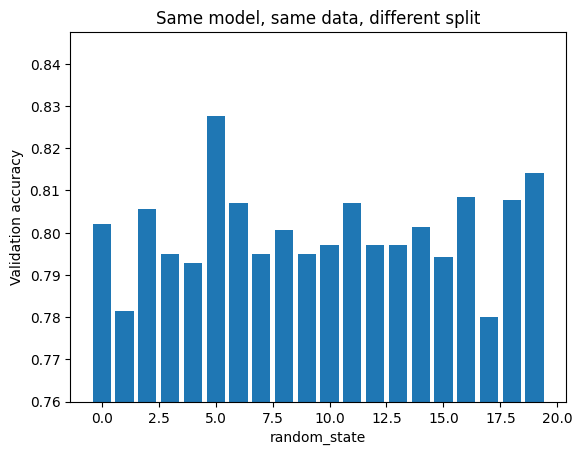

In [20]:
lr = Pipeline([('scale', StandardScaler()),
               ('model', LogisticRegression(max_iter=1000))])
scores = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X_train, y_train, test_size=0.25,
                                      random_state=seed, stratify=y_train)
    scores.append(accuracy_score(yb, lr.fit(Xa, ya).predict(Xb)))
scores = np.array(scores)
print(f'min {scores.min():.3f}  max {scores.max():.3f}  std {scores.std():.4f}')
p, n = scores.mean(), len(yb)
se = np.sqrt(p * (1 - p) / n)
print(f'Theoretical standard error: {se:.4f}  -> 95% CI +/- {1.96 * se:.3f}')
plt.bar(range(20), scores)
plt.ylim(scores.min() - 0.02, scores.max() + 0.02)
plt.xlabel('random_state'); plt.ylabel('Validation accuracy')
plt.title('Same model, same data, different split'); 
plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['roc_auc', 'recall', 'f1']
def cv_report(name, model):
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=metrics)
    row = {'model': name}
    for m in metrics:
        s = r['test_' + m]
        row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'
    return row
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)
print(pd.DataFrame([cv_report('Logistic Regression', lr),
                    cv_report('Random Forest', rf)]).to_string(index=False))

              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.545 +/- 0.042 0.594 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


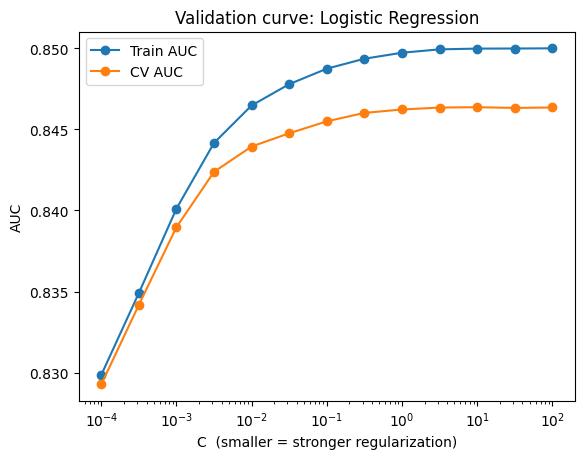

Best C by CV: 10.0


In [22]:
Cs = np.logspace(-4, 2, 13)
tr, va = validation_curve(lr, X_train, y_train, param_name='model__C',
                          param_range=Cs, cv=cv, scoring='roc_auc')
plt.semilogx(Cs, tr.mean(axis=1), 'o-', label='Train AUC')
plt.semilogx(Cs, va.mean(axis=1), 'o-', label='CV AUC')
plt.xlabel('C  (smaller = stronger regularization)'); plt.ylabel('AUC')
plt.legend(); plt.title('Validation curve: Logistic Regression'); plt.show()
print('Best C by CV:', Cs[va.mean(axis=1).argmax()])

In [23]:
grid = {'max_depth': [4, 8, 12, None],
        'min_samples_leaf': [1, 5, 20],
        'max_features': ['sqrt', 0.5]}
print('Combinations:', 4 * 3 * 2, ' Fits:', 4 * 3 * 2 * 5)
t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                         random_state=42),
                  grid, cv=cv, scoring='roc_auc')
gs.fit(X_train, y_train)
print(f'Grid:   best AUC {gs.best_score_:.4f}  in {time.time() - t0:.0f}s')
print(gs.best_params_)

Combinations: 24  Fits: 120
Grid:   best AUC 0.8468  in 125s
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


In [24]:
dist = {'max_depth': randint(3, 20),
        'min_samples_leaf': randint(1, 40),
        'max_features': uniform(0.1, 0.8)}   # fraction of features
t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                               random_state=42),
                        dist, n_iter=24, cv=cv, scoring='roc_auc',
                        random_state=42)
rs.fit(X_train, y_train)
print(f'Random: best AUC {rs.best_score_:.4f}  in {time.time() - t0:.0f}s')
print(rs.best_params_)
res = pd.DataFrame(rs.cv_results_)
cols = ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score',
        'std_test_score', 'rank_test_score']
print(res[cols].sort_values('rank_test_score').head(5).to_string(index=False))

Random: best AUC 0.8464  in 126s
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}
 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


In [25]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {spw:.2f}')
xgb = XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', early_stopping_rounds=100,
                    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)
print('Best number of trees:', xgb.best_iteration + 1)
val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f'Validation AUC: {val_auc:.4f}')

scale_pos_weight = 2.77
Best number of trees: 247
Validation AUC: 0.8541


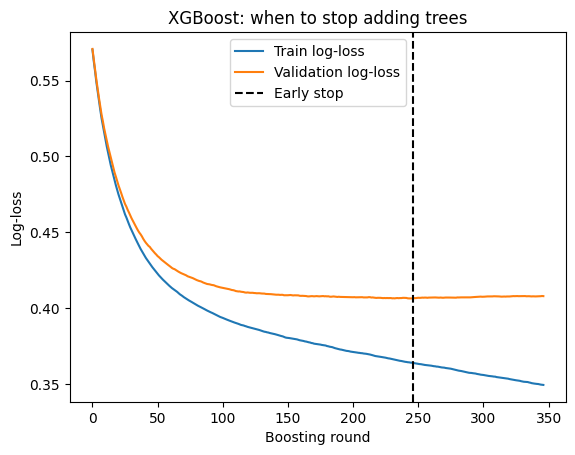

In [26]:
ev = xgb.evals_result()
plt.plot(ev['validation_0']['logloss'], label='Train log-loss')
plt.plot(ev['validation_1']['logloss'], label='Validation log-loss')
plt.axvline(xgb.best_iteration, color='k', ls='--', label='Early stop')
plt.xlabel('Boosting round'); plt.ylabel('Log-loss')
plt.legend(); plt.title('XGBoost: when to stop adding trees');
plt.show()

In [27]:
xdist = {'max_depth': randint(2, 7),
         'learning_rate': loguniform(0.01, 0.3),
         'n_estimators': randint(100, 600),
         'subsample': uniform(0.6, 0.4),
         'colsample_bytree': uniform(0.5, 0.5),
         'min_child_weight': randint(1, 10),
         'reg_lambda': loguniform(0.1, 10)}
xs = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42,
                                      n_jobs=-1),
                        xdist, n_iter=30, cv=cv, scoring='roc_auc',
                        random_state=42)
xs.fit(X_train, y_train)
print(f'XGBoost tuned CV AUC: {xs.best_score_:.4f}')
print({k: round(v, 3) if isinstance(v, float) else v
       for k, v in xs.best_params_.items()})

XGBoost tuned CV AUC: 0.8502
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


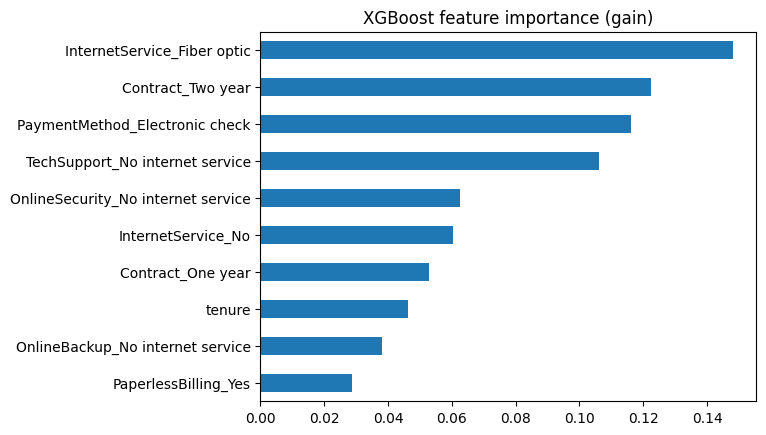

In [28]:
imp = pd.Series(xs.best_estimator_.feature_importances_, index=X.columns)
imp.sort_values().tail(10).plot.barh(title='XGBoost feature importance (gain)')
plt.show()

In [29]:
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
seg = df[seg_cols].copy()
seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)
Z = StandardScaler().fit_transform(seg)   # distances need equal scales
print(seg.describe().round(1))

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


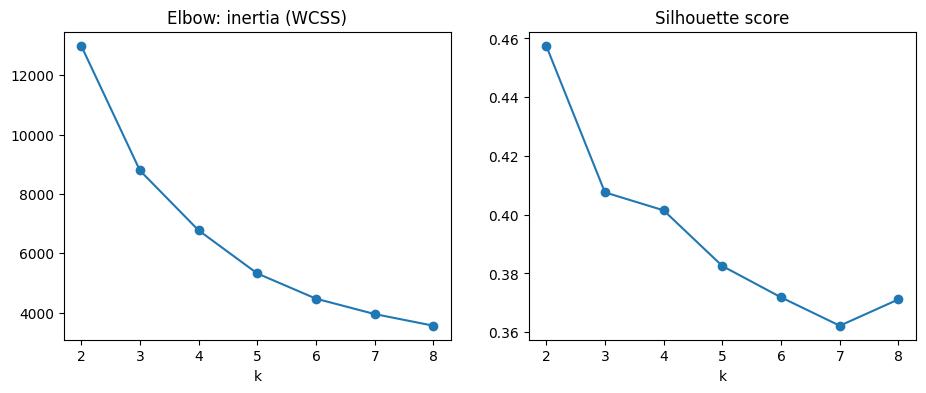

In [30]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_, sample_size=3000,
                                random_state=42))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, 'o-'); ax[0].set_title('Elbow: inertia (WCSS)')
ax[1].plot(ks, sil, 'o-'); ax[1].set_title('Silhouette score')
for a in ax: a.set_xlabel('k')
plt.show()

In [31]:
k = 4   # choose from the elbow and silhouette plots, then justify it
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
seg['cluster'] = km.labels_
# Churn was NOT used to form clusters. We use it only to profile them.
profile = seg.assign(churn=y).groupby('cluster').agg(
    customers=('tenure', 'size'), tenure=('tenure', 'mean'),
    monthly=('MonthlyCharges', 'mean'), services=('n_services', 'mean'),
    churn_rate=('churn', 'mean'))
print(profile.round(2).sort_values('churn_rate', ascending=False))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


Components for 90% variance: 15 of 30


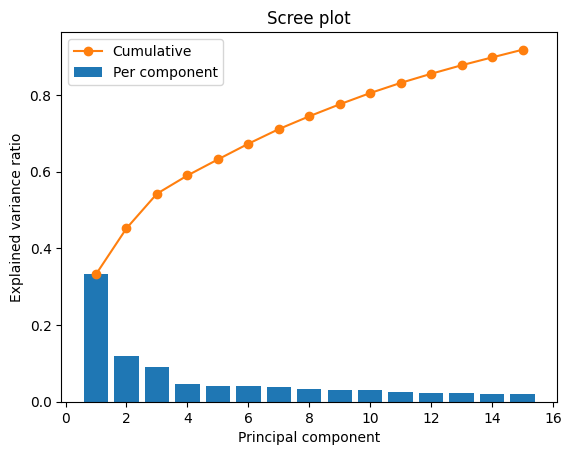

In [32]:
Xs = StandardScaler().fit_transform(X_train)
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
print('Components for 90% variance:', np.argmax(cum >= 0.90) + 1,
      'of', X_train.shape[1])
plt.bar(range(1, 16), pca.explained_variance_ratio_[:15], label='Per component')
plt.plot(range(1, 16), cum[:15], 'o-', color='C1', label='Cumulative')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Scree plot'); 
plt.show()

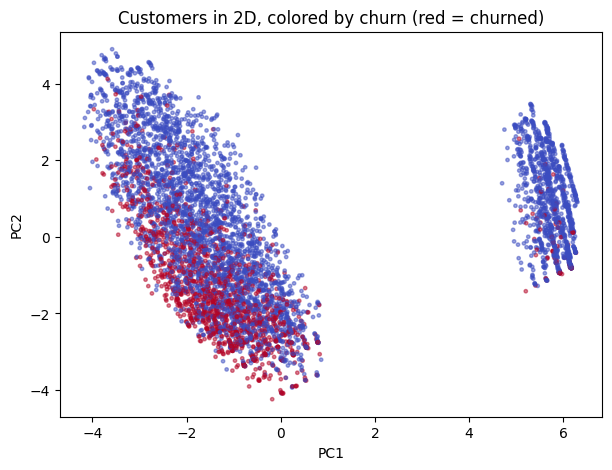

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
dtype: float64


In [33]:
P = PCA(n_components=2).fit(Xs)
T = P.transform(Xs)
plt.figure(figsize=(7, 5))
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='coolwarm', s=6, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Customers in 2D, colored by churn (red = churned)'); plt.show()
load = pd.Series(P.components_[0], index=X.columns)
print('PC1 top loadings:')
order = load.abs().sort_values(ascending=False).index
print(load.reindex(order).head(6).round(3))

In [34]:
candidates = {
    'LR (tuned C)': lr.set_params(model__C=Cs[va.mean(axis=1).argmax()]),
    'RF (random search)': rs.best_estimator_,
    'XGBoost (tuned)': xs.best_estimator_,
}
rows = []
for name, m in candidates.items():
    cvs = cross_validate(m, X_train, y_train, cv=cv, scoring='roc_auc')
    rows.append({'model': name,
                 'cv_auc': cvs['test_score'].mean(),
                 'cv_std': cvs['test_score'].std()})
cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))

             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8502  0.0117


In [35]:
best_name = cmp.loc[cmp['cv_auc'].idxmax(), 'model']  # chosen by CV only
best = candidates[best_name].fit(X_train, y_train)
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print(f'{best_name} on the test set (used once):')
print(f'AUC {roc_auc_score(y_test, prob):.4f}  '
      f'recall {recall_score(y_test, pred):.3f}  '
      f'precision {precision_score(y_test, pred):.3f}')
joblib.dump(best, 'churn_model.joblib') 

XGBoost (tuned) on the test set (used once):
AUC 0.8483  recall 0.521  precision 0.659


['churn_model.joblib']